# NMEA simulator for debugging aragnoid
create a stream of NMEA messages to simulate driving on a field
this makes debugging easier than actually driving around 


In [89]:

import numpy as np
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import math
import serial
import time as tme


In [137]:
def utc(time):
    #construct a semi valid utc time
    times=math.fmod(time,60)
    minutes=np.floor(time/60)
    print(times)
    print(minutes)
    gtime=180000.00+times+minutes*100#in hhmmss.ss
    return gtime

In [210]:
def sendgpgga(time,posx,posy):
    #checksum is not correct but arduino doesnt test it anyway
    #example
    #$GPGGA,183538.70,5056.7186660,N,00446.6231208,E,4,12,0.64,17.998,M,46.220,M,0.7,4035*48
    scale=0.0009 #1m to degrees
    npos=posx*scale+5056.7186660
    epos=posy*scale+0446.6231208

    gtime=utc(time)
    
    msg="$GPGGA,"+f"{gtime:.2f}"+","+f"{npos:012.7f}"+",N,"+f"{epos:013.7f}"+",E,4,12,0.64,17.998,M,46.220,M,,*48\n"
    return msg

In [235]:

def sendvtg(heading,speed):
    #checksum isnt correct but arduino doesnt check it anyway and makes its own
    #$GNVTG,335.788,T,335.788,M,0.001,N,0.002,K,A*3E
    heading=-heading+90.0
    if (heading<0):
        heading+=360.0
    if heading>=360.0:
        heading-=360
    speedk=speed*0.539956803
    #msg="$GNVTG,"+f"{heading:.2f}"+",T,"+ f"{heading:.2f}" +",M,"+ f"{speedk:.3f}"+",N,"+f"{speed:.3f}"+",K,D*3E\n"
    msg="$GNVTG,"+f"{heading:.2f}"+",T,,M,"+ f"{speedk:.3f}"+",N,"+f"{speed:.3f}"+",K,D*3E\n"
    
    return msg


In [ ]:
def sendzda(time):
    #$GPZDA,172809.456,12,07,1996,00,00*45
    gtime=utc(time)
    msg="$GPZDA,"+f"{gtime:.2f}"+",03,08,2026,,*45\n"
    return msg

In [249]:
#define the field in m and create a list of coordinates and headings
nrows=3
ncolls=5
rowlength=50
collwidth=20
overlap=0
speedkmh=7 #kmh
speed=speedkmh/3.6 #in m/s
origx=0
origy=0
totallength=nrows*rowlength*ncolls
dt=0.1 #time between updates
step=speed*dt


#kopakker steps
kopreduction=0.5 #lower speed by this fraction
koplength=np.pi*(collwidth-overlap)/2 #length of semicircle
kopspeed=speed*kopreduction
koptime=koplength/kopspeed
kopsteps=int(koptime/dt)





#simulate reversing section
rstep=20 #number of steps in reverse
interval=200 #number of timesteps between reversing 


tottime=totallength/speed+(koplength*ncolls)/(speed*kopreduction)

timesteps=int(totallength/(speed*dt)+kopsteps)


print(tottime)
print(step)
print(kopsteps)
print(koptime)

posx=origx
posy=origy
direction=1
time=0


extra=20
tlist=np.zeros(timesteps+extra)
xlist=np.zeros(timesteps+extra)
ylist=np.zeros(timesteps+extra)
hlist=np.zeros(timesteps+extra)
slist=np.zeros(timesteps+extra)

t=0
while t<timesteps:
    t+=1
    time+=dt
    posx+=direction*step
    if (posx-origx)>rowlength or (posx-origx)<0:
        startkopx=posx
        startkopy=posy
        #print('starting kopsection')
        for it in range(kopsteps):
            theta=direction*((it+1)/kopsteps)*np.pi
            #print(theta)
            radius=(collwidth-overlap)/2
            oldx=posx
            oldy=posy
            posx=startkopx+np.sin(theta)*radius
            posy=(startkopy-radius)+np.cos(theta)*radius
            dx=posx-oldx
            dy=posy-oldy
            heading=np.atan2(dx,dy)*180/np.pi

            
            tlist[t]=time
            xlist[t]=posx
            ylist[t]=posy
            hlist[t]=heading
            slist[t]=kopspeed*3.6
            time+=dt
            t+=1
        direction=-direction
    if t%interval==0:
        direction=-direction #reverse
        for ir in range(rstep):
            oldx=posx
            oldy=posy
            posx+=direction*step
            dx=posx-oldx
            dy=posy-oldy
            heading=np.atan2(dx,dy)*180/np.pi
            tlist[t]=time
            xlist[t]=posx
            ylist[t]=posy
            hlist[t]=heading
            time+=dt
            t+=1
        direction=-direction 

    tlist[t]=time
    currspeed=speed*3.6
    heading=direction*90
    xlist[t]=posx
    ylist[t]=posy
    hlist[t]=heading
    slist[t]=speedkmh

    


547.2819078989037
0.19444444444444445
323
32.313524436923586


IndexError: index 4200 is out of bounds for axis 0 with size 4200

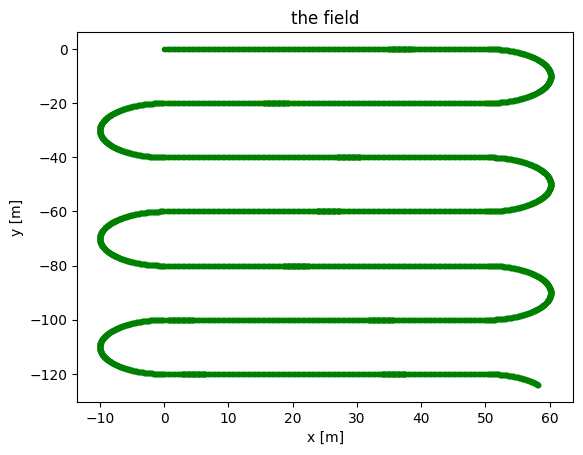

In [250]:
# show the field and the headings
plt.figure()
plt.title('the field')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
#plt.ylim(0, collwidth*ncolls)
#plt.xlim(0, rowlength)
plt.plot(xlist,ylist,'g.')
vx=slist*np.sin(hlist*np.pi/180)
vy=slist*np.cos(hlist*np.pi/180)

plt.quiver(xlist,ylist,vx,vy)


In [251]:
# send it out to serial if possible

with serial.Serial('/dev/cu.usbserial-0001', 115200, timeout=1) as ser:
    while 1:
        for t in range(timesteps):
            time=tlist[t]
            speed=slist[t]
            posx=xlist[t]
            posy=ylist[t]
            heading=hlist[t]
            msg=sendgpgga(time,posx,posy)
            print(msg)
            ser.write(msg.encode('utf-8'))  
            msg=sendvtg(heading,speed)
            print(msg)
            ser.write(msg.encode('utf-8'))  
            if  t%10==0:
                msg=sendzda(time)
                print(msg)
                ser.write(msg.encode('utf-8'))  
            tme.sleep(dt)

    

    

0.0
0.0
$GPGGA,180000.00,5056.7186660,N,00446.6231208,E,4,12,0.64,17.998,M,46.220,M,,*48

$GNVTG,90.00,T,,M,0.000,N,0.000,K,D*3E

0.0
0.0
$GPZDA,180000.00,12,07,1996,,*45

0.1
0.0
$GPGGA,180000.10,5056.7188410,N,00446.6231208,E,4,12,0.64,17.998,M,46.220,M,,*48

$GNVTG,0.00,T,,M,3.780,N,7.000,K,D*3E

0.2
0.0
$GPGGA,180000.20,5056.7190160,N,00446.6231208,E,4,12,0.64,17.998,M,46.220,M,,*48

$GNVTG,0.00,T,,M,3.780,N,7.000,K,D*3E

0.30000000000000004
0.0
$GPGGA,180000.30,5056.7191910,N,00446.6231208,E,4,12,0.64,17.998,M,46.220,M,,*48

$GNVTG,0.00,T,,M,3.780,N,7.000,K,D*3E

0.4
0.0
$GPGGA,180000.40,5056.7193660,N,00446.6231208,E,4,12,0.64,17.998,M,46.220,M,,*48

$GNVTG,0.00,T,,M,3.780,N,7.000,K,D*3E

0.5
0.0
$GPGGA,180000.50,5056.7195410,N,00446.6231208,E,4,12,0.64,17.998,M,46.220,M,,*48

$GNVTG,0.00,T,,M,3.780,N,7.000,K,D*3E

0.6
0.0
$GPGGA,180000.60,5056.7197160,N,00446.6231208,E,4,12,0.64,17.998,M,46.220,M,,*48

$GNVTG,0.00,T,,M,3.780,N,7.000,K,D*3E

0.7
0.0
$GPGGA,180000.70,5056.7198910,

KeyboardInterrupt: 